
<!-- # Chương 1: Đánh giá Toàn diện Thuật toán FP-Growth
Dataset: `chess.dat`

Notebook này được chia thành 3 phần kiểm thử độc lập:
1. **Correctness (Tính đúng đắn):** `eval_correctness()` và `vis_correctness()`
2. **Performance (Hiệu năng):** `eval_performance()` và `vis_performance()`
3. **Scalability (Khả năng mở rộng):** `eval_scalability()` và `vis_scalability()` -->

# Evaluate

## Dependencies

In [ ]:
import Pkg
deps = Pkg.project().dependencies
for pkg in ["DataFrames", "CSV", "Plots"]
    if !haskey(deps, pkg)
        Pkg.add(pkg)
    end
end

using CSV
using DataFrames
using Random
using Plots
using Plots.PlotMeasures
using ProgressMeter
using Statistics
gr()

include("../src/FPGrowth.jl")
using .FPGrowth
include("../src/logger.jl")
include("../src/utils.jl")
using .Utils
logger = Logger()

success(logger, "Dependencies loaded")


## Helpers

In [ ]:
include("../src/eval.jl")
using .Utils
success(logger, "Helper loaded")


# Unit Tests (Toy Datasets)
Kiểm thử tự động trên 5 CSDL thử nghiệm (Toy datasets) nhằm tái tạo đúng kết quả, đối chiếu với SPMF theo yêu cầu đồ án.

### **Test 1**

In [ ]:
cd("..") do
    run(`julia --project main.jl 
               --input data/toy/test1.txt 
               --minsup 0.4
               --output results/result1.txt`)
end


### **Test 2**

In [ ]:
cd("..") do
    run(`julia --project main.jl 
               --input data/toy/test2.txt 
               --minsup 0.4
               --output results/result2.txt`)
end


### **Test 3**

In [ ]:
cd("..") do
    run(`julia --project main.jl 
               --input data/toy/test3.txt 
               --minsup 0.4
               --output results/result3.txt`)
end


### **Test 4**

In [ ]:
cd("..") do
    run(`julia --project main.jl 
               --input data/toy/test4.txt 
               --minsup 0.4
               --output results/result4.txt`)
end


### **Test 5**

In [ ]:
cd("..") do
    run(`julia --project main.jl 
               --input data/toy/test5.txt 
               --minsup 0.4
               --output results/result5.txt`)
end


### Config

In [ ]:
Random.seed!(42)
CONFIG = Dict(
    "spmf_path" => "../spmf.jar",
    "java_path" => "C:/Program Files/Microsoft/jdk-21.0.10.7-hotspot/bin/java.exe",
    "Minimum Support" => 0.4,
    
    # File dành riêng cho Optimization Benchmark (Dữ liệu lớn)
    "dataset_path" => "../data/benchmark/connect-4.dat", 
    
    # Danh sách file dành cho Unit Test (Dữ liệu nhỏ)
    "datasets_path" => [
        "../data/toy/test1.txt",
        "../data/toy/test2.txt",
        "../data/toy/test3.txt",
        "../data/toy/test4.txt",
        "../data/toy/test5.txt"
    ],
    "results_path" => ["../results/"]
)

if !isdir("../results") mkdir("../results") end
success(logger, "Config loaded")


In [ ]:
accuracy = run_unitTest(CONFIG, logger)


## Optimization Evaluation (Basic vs Optimized)
So sánh hiệu năng giữa phiên bản FP-Growth cơ bản và phiên bản đã được tối ưu hóa.

In [1]:
import Pkg
deps = Pkg.project().dependencies
for pkg in ["DataFrames", "CSV", "Plots"]
    if !haskey(deps, pkg)
        Pkg.add(pkg)
    end
end

using CSV
using DataFrames
using Random
using Plots
using Plots.PlotMeasures
using ProgressMeter
using Statistics
gr()

include("../src/FPGrowth.jl")
using .FPGrowth
include("../src/logger.jl")
include("../src/utils.jl")
using .Utils
logger = Logger()

success(logger, "Dependencies loaded")
include("../src/eval.jl")
using .Utils
success(logger, "Helper loaded")

Random.seed!(42)


[success] Dependencies loaded
[success] Helper loaded


TaskLocalRNG()

In [2]:

CONFIG = Dict(
    "spmf_path" => "../spmf.jar",
    "java_path" => "C:/Program Files/Microsoft/jdk-21.0.10.7-hotspot/bin/java.exe",
    "Minimum Support" => 0.8,
    
    # File dành riêng cho Optimization Benchmark (Dữ liệu lớn)
    "dataset_path" => "../data/benchmark/connect-4.dat", 
    
    # Danh sách file dành cho Unit Test (Dữ liệu nhỏ)
    "results_path" => ["../results/"]
)

if !isdir("../results") mkdir("../results") end
success(logger, "Config loaded")



[success] Config loaded



__________________________________________________
[phase]  OPTIMIZATION COMPARISON
__________________________________________________
[info] Comparing Basic vs Optimized version on: connect-4.dat
[info] Threshold MinSup=80.0%
[process] Running Basic FPGrowth...
[process] Running Optimized FPGrowth (Single Path Pruning + BitArray)...
[success] ✓ Internal Consistency: Basic and Optimized versions match (533975 itemsets)
[process] Verifying results against SPMF Java baseline...
[success] ✓ SPMF Verified: Julia results are identical to SPMF Java.
   [metric] Basic Time: 0.7992s
   [metric] Optimized Time: 0.6369s
[success] Improvement: 20.31% faster

__________________________________________________
[phase]  visualize
__________________________________________________


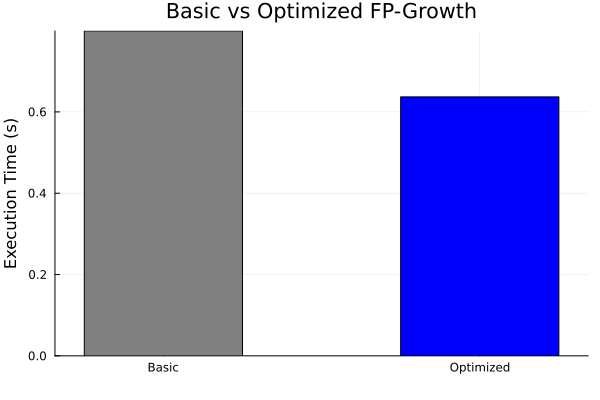

In [3]:
opt_results = eval_optimization(CONFIG, logger)
vis_optimization(opt_results, logger)
